# Introduction to reranking: an advanced RAG technique

In this notebook, you will test an advanced RAG technique: using a reranker (CrossEncoder model) to improve the retrieval of news in a RAG pipeline.

The notebook is partially filled with code. You will complete it by writing the missing code, running evaluations, and comparing results.

# 📌 Objectives

By the end of this notebook, students will be able to:

1. **Create and Use a Synthetic Evaluation Dataset:**
   - Automatically generate natural language questions corresponding to news articles using an LLM.
   - Construct a test set to assess the quality of retrieved answers.

2. **Evaluate Baseline RAG Performance Without Reranking:**
   - Measure how often the original article appears in the top-k results using FAISS alone.
   - Record retrieval accuracy and position for each query.

3. **Apply a Cross-Encoder Reranker to Improve Retrieval:**
   - Use a pretrained CrossEncoder model to rerank top FAISS results.
   - Evaluate improvements in the ranking of correct articles after reranking.

4. **Compare Retrieval Performance With and Without Reranking:**
   - Compute and visualize differences in rank positions before and after reranking.
   - Analyze statistical improvements (e.g., average rank, frequency at position 0).

5. **Reflect on the Impact of Reranking in RAG Pipelines:**
   - Discuss how reranking enhances retrieval quality in a RAG context.
   - Identify scenarios where reranking may offer the most value, and propose further improvements.


## Install and Import librairies
Run the following cell to install required libraries. These include `sentence-transformers` for embeddings and reranking, and `faiss-cpu` for vector similarity search.

In [1]:
%pip install sentence-transformers
%pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 40.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [2]:
from sentence_transformers import SentenceTransformer
import faiss
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import matplotlib.pyplot as plt
import faiss

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load S&P 500 news
We will work with a dataset of financial news headlines and summaries. You will:
 - Load the data
 - Convert the publication date column to datetime
 - Drop duplicate summaries

In [4]:
df_news = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Fintech/df_news.csv')
df_news['PUBLICATION_DATE'] = pd.to_datetime(df_news['PUBLICATION_DATE']).dt.date
display(df_news)
print(df_news.shape)

df_news.drop_duplicates('SUMMARY', inplace=True)
print(df_news.shape)

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,PROVIDER,URL
0,MMM,2 Dow Jones Stocks with Promising Prospects an...,The Dow Jones (^DJI) is made up of 30 of the m...,2025-05-29,StockStory,https://finance.yahoo.com/news/2-dow-jones-sto...
1,MMM,3 S&P 500 Stocks Skating on Thin Ice,The S&P 500 (^GSPC) is often seen as a benchma...,2025-05-27,StockStory,https://finance.yahoo.com/news/3-p-500-stocks-...
2,MMM,3M Rises 15.8% YTD: Should You Buy the Stock N...,"MMM is making strides in the aerospace, indust...",2025-05-22,Zacks,https://finance.yahoo.com/news/3m-rises-15-8-y...
3,MMM,Q1 Earnings Roundup: 3M (NYSE:MMM) And The Res...,Quarterly earnings results are a good time to ...,2025-05-22,StockStory,https://finance.yahoo.com/news/q1-earnings-rou...
4,MMM,3 Cash-Producing Stocks with Questionable Fund...,While strong cash flow is a key indicator of s...,2025-05-19,StockStory,https://finance.yahoo.com/news/3-cash-producin...
...,...,...,...,...,...,...
4866,ZTS,2 Dividend Stocks to Buy With $500 and Hold Fo...,Zoetis is a leading animal health company with...,2025-05-23,Motley Fool,https://www.fool.com/investing/2025/05/23/2-di...
4867,ZTS,Zoetis (NYSE:ZTS) Declares US$0.50 Dividend Pe...,Zoetis (NYSE:ZTS) recently affirmed a dividend...,2025-05-22,Simply Wall St.,https://finance.yahoo.com/news/zoetis-nyse-zts...
4868,ZTS,Jim Cramer on Zoetis (ZTS): “It Does Seem to B...,We recently published a list of Jim Cramer Tal...,2025-05-21,Insider Monkey,https://finance.yahoo.com/news/jim-cramer-zoet...
4869,ZTS,Zoetis (ZTS) Upgraded to Buy: Here's Why,Zoetis (ZTS) might move higher on growing opti...,2025-05-21,Zacks,https://finance.yahoo.com/news/zoetis-zts-upgr...


(4871, 6)
(3976, 6)


## Implement a Faiss Vector Store with Sentence Transfomer embeddings
This section is already implemented. It uses a sentence transformer to encode news summaries into vector embeddings and stores them in a FAISS index.

We also define a simple class `FaissVectorStore` that allows for efficient retrieval.


In [5]:
df_news['EMBEDDED_TEXT'] = df_news['TITLE'] + ' : ' + df_news['SUMMARY']

In [6]:
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [7]:
# Load model and compute embeddings
text_embeddings = model.encode(df_news['SUMMARY'].tolist(), convert_to_numpy=True)

# Normalize embeddings to use cosine similarity (via inner product in FAISS)
text_embeddings = text_embeddings / np.linalg.norm(text_embeddings, axis=1, keepdims=True)

# Prepare metadata
documents = df_news['SUMMARY'].tolist()
metadata = [
    {
        'PUBLICATION_DATE': row['PUBLICATION_DATE'],
        'TICKER': row['TICKER'],
        'PROVIDER': row['PROVIDER']
    }
    for _, row in df_news.iterrows()
]

In [8]:
embedding_dim = text_embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(embedding_dim)  # Cosine similarity via inner product
faiss_index.add(text_embeddings)

In [9]:
class FaissVectorStore:
    def __init__(self, model, index, embeddings, documents, metadata):
        self.model = model
        self.index = index
        self.embeddings = embeddings
        self.documents = documents
        self.metadata = metadata

    def search(self, query, k=5, metadata_filter=None):
        query_embedding = self.model.encode([query])
        query_embedding = query_embedding / np.linalg.norm(query_embedding)

        if metadata_filter:
            filtered_indices = [i for i, meta in enumerate(self.metadata) if metadata_filter(meta)]
            if not filtered_indices:
                return []
            filtered_embeddings = self.embeddings[filtered_indices]
            temp_index = faiss.IndexFlatIP(filtered_embeddings.shape[1])
            temp_index.add(filtered_embeddings)
            D, I = temp_index.search(query_embedding, k)
            indices = [filtered_indices[i] for i in I[0]]
        else:
            D, I = self.index.search(query_embedding, k)
            indices = I[0]
            D = D[0]

        results = []
        for idx, sim in zip(indices, D):
            results.append((self.documents[idx], self.metadata[idx], float(sim)))


        return results

In [10]:
# Create FAISS-based store
faiss_store = FaissVectorStore(
    model=model,
    index=faiss_index,
    embeddings=text_embeddings,
    documents=documents,
    metadata=metadata
)

## Creating a dataset to evaluate the reranking

👉 **Instructions**:
- In this section, we will create an evaluation dataset for reranking by:
  - Sampling **100** distinct news articles from the full dataset.
  - Generating **one natural question** per article using GPT, where the expected answer is the original article.

✅ By the end of this section, you'll have a new DataFrame (`df_news_questions`) with:
- `NEWS`: the original summary
- `QUESTION`: the corresponding question generated using GPT

> ℹ️ The generated questions will simulate user queries in a RAG pipeline.

In [11]:
# CODE HERE
# Use as many coding cells as you need
df_news_questions=pd.DataFrame(columns=['Question'])
df_news_questions

,Question


In [12]:
df_news_questions['NEWS']=df_news['SUMMARY'].sample(100, random_state=42)
df_news_questions['Question']=''
df_news_questions

,Question,NEWS
427,,"Broadcom, Arista Networks initiated: Wall Stre..."
1600,,Emerson Electric (EMR) has received quite a bi...
728,,Ventas (VTR) reported earnings 30 days ago. Wh...
3769,,Nvidia's earnings call this week will be a mar...
2711,,Inflation-scarred American consumers are putti...
...,...,...
4196,,T. Rowe Price Group ( NASDAQ:TROW ) First Quar...
2525,,"Heartland Advisors, an investment management c..."
3620,,Key Insights Given the large stake in the stoc...
1566,,The study found that early intervention led to...


In [13]:
df_news_questions.reset_index(drop=True, inplace=True)
df_news_questions

,Question,NEWS
0,,"Broadcom, Arista Networks initiated: Wall Stre..."
1,,Emerson Electric (EMR) has received quite a bi...
2,,Ventas (VTR) reported earnings 30 days ago. Wh...
3,,Nvidia's earnings call this week will be a mar...
4,,Inflation-scarred American consumers are putti...
...,...,...
95,,T. Rowe Price Group ( NASDAQ:TROW ) First Quar...
96,,"Heartland Advisors, an investment management c..."
97,,Key Insights Given the large stake in the stoc...
98,,The study found that early intervention led to...


### Create OpenAI connector
You’ll use OpenAI’s GPT model to generate natural questions corresponding to each sampled news summary. These questions will be used to test the retrieval system.

✅ This cell contains an API key for demonstration purposes. You **must** use your own API key when running this notebook.


In [14]:
sk_gpt='/content/drive/MyDrive/Colab Notebooks/sk_gpt.py'
exec(open(sk_gpt).read())

In [15]:
from openai import OpenAI
client = OpenAI(api_key = my_sk)

response = client.responses.create(
    model="gpt-4o-mini",
    input="Write a one-sentence bedtime story about a unicorn."
)

print(response.output_text)

As the moonlit sky shimmered with stars, a lonely unicorn named Luna discovered a hidden grove where every wish whispered to the wind blossomed into a magical flower, filling her heart with hope and joy.


### Using GPT to generate a question based on a news
Based on the instruction above, you need to use GPT to create a evaluation dataset.

**Clarification** Specifically, the goal is to generate a natural question whose correct answer is the news summary. For example, if the news is about a company announcing layoffs, a good question could be: ‘Which company recently announced job cuts in its tech division?


In [16]:
prompt = """
Given the news headline provided below,
give me a question that would justify retrieving this specific news headline in a RAG system

News headlines:
{news}

Give me a question for which the answer is the news headline:
QUESTION

**Important**
dont answer anything else other than the question!
"""

In [17]:
# CODE HERE
# Use as many coding cells as you need
from openai import OpenAI
client = OpenAI(api_key = my_sk)
for i in range(len(df_news_questions)):
  response=client.chat.completions.create(
      model="gpt-4o-mini",
      messages=[
          {"role": "system", "content": prompt},
          {"role": "user", "content": df_news_questions['NEWS'][i]}
      ]
  )
  print(df_news_questions['NEWS'][i])
  print(response.choices[0].message.content)
  print('--------------------------------------------------------')
  df_news_questions['Question'][i]=response.choices[0].message.content

Broadcom, Arista Networks initiated: Wall Street's top analyst calls
What are the latest analyst recommendations for Broadcom and Arista Networks?
--------------------------------------------------------


/tmp/ipython-input-2500337858.py:16: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_news_questions['Question'][i]=response.choices[0].message.content


Emerson Electric (EMR) has received quite a bit of attention from Zacks.com users lately. Therefore, it is wise to be aware of the facts that can impact the stock's prospects.
What recent developments have drawn attention to Emerson Electric (EMR) among Zacks.com users?
--------------------------------------------------------


/tmp/ipython-input-2500337858.py:16: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_news_questions['Question'][i]=response.choices[0].message.content


Ventas (VTR) reported earnings 30 days ago. What's next for the stock? We take a look at earnings estimates for some clues.
What did Ventas (VTR) report regarding their earnings 30 days ago and what are the implications for the stock moving forward?
--------------------------------------------------------


...

/tmp/ipython-input-2500337858.py:16: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_news_questions['Question'][i]=response.choices[0].message.content


The study found that early intervention led to an 80% reduction in heart failure hospitalisations one year after treatment.
What did the study conclude about the impact of early intervention on heart failure hospitalisations one year after treatment?
--------------------------------------------------------


/tmp/ipython-input-2500337858.py:16: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_news_questions['Question'][i]=response.choices[0].message.content


US authorities are preparing to announce one of the biggest cuts in banks’ capital requirements for more than a decade, marking the latest sign...
What recent action are US authorities preparing to announce regarding banks' capital requirements?
--------------------------------------------------------


/tmp/ipython-input-2500337858.py:16: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_news_questions['Question'][i]=response.choices[0].message.content


In [18]:
df_news_questions

,Question,NEWS
0,What are the latest analyst recommendations fo...,"Broadcom, Arista Networks initiated: Wall Stre..."
1,What recent developments have drawn attention ...,Emerson Electric (EMR) has received quite a bi...
2,What did Ventas (VTR) report regarding their e...,Ventas (VTR) reported earnings 30 days ago. Wh...
3,What are the key points to watch for in Nvidia...,Nvidia's earnings call this week will be a mar...
4,What are American consumers doing as they cope...,Inflation-scarred American consumers are putti...
...,...,...
95,What were T. Rowe Price Group's key financial ...,T. Rowe Price Group ( NASDAQ:TROW ) First Quar...
96,What investment management company released it...,"Heartland Advisors, an investment management c..."
97,What factors might affect Phillips 66's stock ...,Key Insights Given the large stake in the stoc...
98,What did the study conclude about the impact o...,The study found that early intervention led to...


## Evaluating RAG without and with reranking

You will now compare a basic RAG pipeline using FAISS with an enhanced version that includes reranking.


### RAG without reranking

👉 **Instructions**:
1. Implement a function that retrieves the **top 5** news summaries for a given question using your FAISS vector store.
2. For each `(QUESTION, NEWS)` pair:
   - Search using the `QUESTION`
   - Check if the corresponding `NEWS` appears in the top 5 retrieved summaries.
   - Record the **rank position** (from 0 to 4) in a new column `NO_RERANKER`.
   - If the news is **not found**, store `'not found'`.

✅ This step helps measure the baseline performance of your vector-based retrieval without reranking.

> 💡 Tip: You can store the retrieved results in a dictionary or list to avoid recomputation.

In [19]:
# CODE HERE
# Use as many coding cells as you need
def evaluate_baseline(df_news_questions, faiss_store, top_k=5):
  q_dict={}
  rerank_positions=[]
  for _,row in df_news_questions.iterrows():
    qs=row['Question']
    new=row['NEWS']

    if qs not in q_dict:
      results=faiss_store.search(qs, k=top_k)
      docs_retrieved=[doc for (doc, meta, sim) in results]
      q_dict[qs]=docs_retrieved
    docs_topk=q_dict[qs]
    if new in docs_topk:
      position=docs_topk.index(new)
    else:
      position='not found'
    rerank=rerank_positions.append(position)
  df_news_questions['NO_RERANKER']=rerank_positions
  return df_news_questions

In [20]:
df_news_questions=evaluate_baseline(df_news_questions, faiss_store, top_k=5)
df_news_questions

,Question,NEWS,NO_RERANKER
0,What are the latest analyst recommendations fo...,"Broadcom, Arista Networks initiated: Wall Stre...",0
1,What recent developments have drawn attention ...,Emerson Electric (EMR) has received quite a bi...,0
2,What did Ventas (VTR) report regarding their e...,Ventas (VTR) reported earnings 30 days ago. Wh...,0
3,What are the key points to watch for in Nvidia...,Nvidia's earnings call this week will be a mar...,0
4,What are American consumers doing as they cope...,Inflation-scarred American consumers are putti...,0
...,...,...,...
95,What were T. Rowe Price Group's key financial ...,T. Rowe Price Group ( NASDAQ:TROW ) First Quar...,0
96,What investment management company released it...,"Heartland Advisors, an investment management c...",0
97,What factors might affect Phillips 66's stock ...,Key Insights Given the large stake in the stoc...,0
98,What did the study conclude about the impact o...,The study found that early intervention led to...,0


### RAG with reranking
In this section, you will add reranking using a cross-encoder model (`ms-marco-MiniLM-L12-v2`) to improve retrieval.

👉 **Instructions**:
1. Retrieve the **top 100** summaries from FAISS for each question.
2. Rerank these summaries using the CrossEncoder model: `cross-encoder/ms-marco-MiniLM-L12-v2`.
For each question, retrieve the top-100 summaries from FAISS, then rerank only those 100 using the CrossEncoder model.
3. Return the **top 5** reranked results.
4. For each `(QUESTION, NEWS)` pair, record the new rank (0–4) of the correct news in a new column: `WITH_RERANKER`.
5. Again, if the news is not found, store `'not found'`.

✅ This step lets you evaluate how much the reranker improves the relevance of retrieved results.

> ℹ️ The CrossEncoder scores each (question, summary) pair individually, so this step may take longer to run.



In [21]:
from sentence_transformers import CrossEncoder

model = CrossEncoder('cross-encoder/ms-marco-MiniLM-L12-v2')
scores = model.predict([
    ("How many people live in Berlin?", "Berlin had a population of 3,520,031 registered inhabitants in an area of 891.82 square kilometers."),
    ("How many people live in Berlin?", "Berlin is well known for its museums."),
])
print(scores)

config.json:   0%|          | 0.00/791 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

[ 9.218912  -4.0780306]


In [25]:
# CODE HERE
# Use as many coding cells as you need

qs_dict={}
new_rerank_positions=[]
for _,row in df_news_questions.iterrows():
  qs=row['Question']
  new=row['NEWS']
  top100=faiss_store.search(qs, k=100)
  docs_100=[doc for (doc, meta, sim) in top100]
  pairs=[(qs,doc) for doc in docs_100]
  scores=model.predict(pairs)

  # Create a list of tuples with scores and documents, then sort and get top 5 documents
  scored_docs = sorted(zip(scores, docs_100), key=lambda x: x[0], reverse=True)
  top5_reranked_summaries = [doc for score, doc in scored_docs[:5]]

  if new in top5_reranked_summaries:
    position=top5_reranked_summaries.index(new)
  else:
    position='not found'
  new_rerank_positions.append(position)

df_news_questions['WITH_RERANKER']=new_rerank_positions
df_news_questions

,Question,NEWS,NO_RERANKER,WITH_RERANKER
0,What are the latest analyst recommendations fo...,"Broadcom, Arista Networks initiated: Wall Stre...",0,0
1,What recent developments have drawn attention ...,Emerson Electric (EMR) has received quite a bi...,0,0
2,What did Ventas (VTR) report regarding their e...,Ventas (VTR) reported earnings 30 days ago. Wh...,0,0
3,What are the key points to watch for in Nvidia...,Nvidia's earnings call this week will be a mar...,0,0
4,What are American consumers doing as they cope...,Inflation-scarred American consumers are putti...,0,0
...,...,...,...,...
95,What were T. Rowe Price Group's key financial ...,T. Rowe Price Group ( NASDAQ:TROW ) First Quar...,0,0
96,What investment management company released it...,"Heartland Advisors, an investment management c...",0,0
97,What factors might affect Phillips 66's stock ...,Key Insights Given the large stake in the stoc...,0,0
98,What did the study conclude about the impact o...,The study found that early intervention led to...,0,0


## Comparison and analysis

👉 **Instructions**:
- Analyze the impact of reranking using your results.
- Write short answers to the following:
  1. Did reranking improve the **average position** of the correct news?
  2. How often was the correct article at **position 0** with and without reranking?
- You may use:
  - Value counts (`.value_counts()`)
  - Descriptive statistics (`.mean()`, `.median()`)
  - Simple plots (e.g. bar charts or histograms)

✅ This is your opportunity to reflect on the performance of the reranker and think critically about retrieval quality.

> ✨ Optional: You can create a summary table comparing the overall accuracy and coverage between the two methods.

In [28]:
# CODE HERE
# Use as many coding cells as you need
df_news_questions.describe().T

,count,unique,top,freq
Question,100,100,What are the latest analyst recommendations fo...,1
NEWS,100,100,"Broadcom, Arista Networks initiated: Wall Stre...",1
NO_RERANKER,100,4,0,90
WITH_RERANKER,100,4,0,96


In [30]:
df_news_questions[['NO_RERANKER','WITH_RERANKER']].value_counts()

NO_RERANKER  WITH_RERANKER
0            0                87
not found    0                 4
1            0                 4
0            2                 2
             1                 1
2            0                 1
not found    not found         1
Name: count, dtype: int64

In [66]:
df_mean=pd.DataFrame(columns=['Values','Rel Frec NR', 'Rel Frec Rerank'])
df_mean['Values']=df_news_questions['NO_RERANKER'].unique()
df_mean['Rel Frec NR']=df_news_questions.groupby('NO_RERANKER')['NO_RERANKER'].count()/len(df_news_questions)
df_mean['Rel Frec Rerank']=df_news_questions.groupby('WITH_RERANKER')['WITH_RERANKER'].count()/len(df_news_questions)
df_mean

,Values,Rel Frec NR,Rel Frec Rerank
0,0,0.90,0.96
1,1,0.04,0.01
2,not found,0.01,0.02
3,2,NaN,NaN


In [75]:
df_clean= df_news_questions[df_news_questions['NO_RERANKER']!='not found']
nr_mean=df_clean['NO_RERANKER'].mean()
print(f'no rerank mean: {nr_mean}')

df_clean= df_news_questions[df_news_questions['WITH_RERANKER']!='not found']
rer_mean=df_clean['WITH_RERANKER'].mean()
print(f'rerank mean: {rer_mean}')

no rerank mean: 0.06315789473684211
rerank mean: 0.050505050505050504


In [74]:
df_clean= df_news_questions[df_news_questions['NO_RERANKER']!='not found']
nr_med=df_clean['NO_RERANKER'].median()
print(f'no rerank median: {nr_med}')

df_clean= df_news_questions[df_news_questions['WITH_RERANKER']!='not found']
rer_med=df_clean['WITH_RERANKER'].median()
print(f'rerank median: {rer_med}')

no rerank median: 0.0
rerank median: 0.0


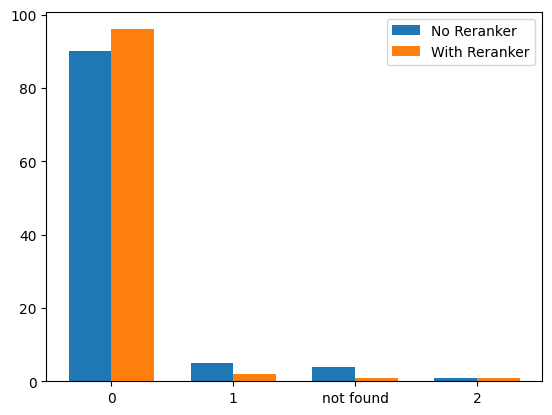

In [53]:
cat=[str(e) for e in df_news_questions['NO_RERANKER'].unique()]
nr_values=df_news_questions['NO_RERANKER'].value_counts()
rerank_values=df_news_questions['WITH_RERANKER'].value_counts()

x=np.arange(len(cat))
width=0.35

plt.bar(x-width/2,nr_values,width,label='No Reranker')
plt.bar(x+width/2,rerank_values,width,label='With Reranker')

plt.xticks(x,cat)
plt.legend()
plt.show()

### **Question 1.** Did reranking improve the **average position** of the correct news?


excluding not found cases, the average position is 0.05 with reranking
without reranking, the average position is 0.06

### **Question 2.** How often was the correct article at **position 0** with and without reranking?


It moved from 90% to 96%. Also, the 1s, and 2s moved positively, and the not found values disappeared.